# SAND Challenge - Task 2: ALS Progression Prediction
## 5-Fold Cross-Validation Approach

## 🎯 Objective
Predict the ALSFRS-R score at the **last follow-up visit** based on:
- Audio features from 8 recordings (5 vowels + 3 syllables)
- Temporal information (months between assessments)
- Initial ALSFRS-R score

## 📊 Task Details
- **Classes**: 4 (ALS with dysarthria levels 1-4, no healthy subjects)
- **Metric**: Averaged F1-Score (macro)
- **Baseline**: PART Algorithm (F1 = 0.583)
- **Current Best**: ISDS Team (F1 = 0.5794)

## 🔬 Evaluation Strategy
**Following professor's guidelines:**
- Combine train + validation sets (132 samples total)
- 5-fold stratified cross-validation
- Report: Mean F1 ± Std across 5 folds

## 🏗️ Approach
1. **Multi-Model Feature Extraction**: Wav2Vec2 + HuBERT
2. **Feature Fusion**: Concatenate audio + temporal features
3. **Ensemble Learning**: Multiple classifiers with 5-fold CV

---

## 1. Setup and Imports

### 1.1 Install Required Packages (if needed)

In [1]:
# Uncomment if packages need to be installed
# !pip install transformers soundfile torch scikit-learn xgboost pandas numpy matplotlib seaborn tqdm imbalanced-learn

### 1.2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor, HubertModel, Wav2Vec2FeatureExtractor
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
from tqdm import tqdm
from scipy.signal import resample
from typing import List, Optional, Tuple, Dict
import json
from datetime import datetime

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    make_scorer, accuracy_score, balanced_accuracy_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully
PyTorch version: 2.9.1
CUDA available: False


---
## 2. Configuration

### 2.1 Paths and Global Settings

In [3]:
# ============================================================================
# PATHS - ADJUST THESE TO YOUR SYSTEM
# ============================================================================
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2')
EXCEL_PATH = DATA_PATH / 'sand_task_2.xlsx'
TASK_DIR = DATA_PATH / 'training'

# Output directory for results
OUTPUT_DIR = Path('../experiments/task2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Configuration loaded")
print(f"  Data Path: {DATA_PATH}")
print(f"  Excel Path: {EXCEL_PATH}")
print(f"  Task Directory: {TASK_DIR}")
print(f"  Output Directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Data Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2
  Excel Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2/sand_task_2.xlsx
  Task Directory: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2/training
  Output Directory: ../experiments/task2


### 2.2 Cross-Validation Configuration

In [4]:
# ============================================================================
# CROSS-VALIDATION SETTINGS (Following Professor's Guidelines)
# ============================================================================
N_FOLDS = 5
CV_RANDOM_STATE = 42

print("="*80)
print("CROSS-VALIDATION CONFIGURATION")
print("="*80)
print(f"Strategy: {N_FOLDS}-Fold Stratified Cross-Validation")
print(f"Data: Combined Train + Validation sets")
print(f"Reporting: Mean ± Std over {N_FOLDS} runs")
print("="*80)

CROSS-VALIDATION CONFIGURATION
Strategy: 5-Fold Stratified Cross-Validation
Data: Combined Train + Validation sets
Reporting: Mean ± Std over 5 runs


### 2.3 Feature Extraction Configuration

We'll use **two complementary models** for robust feature extraction:
- **Wav2Vec2**: Contrastive learning-based representations
- **HuBERT**: Clustering-based masked prediction

In [5]:
# ============================================================================
# FEATURE EXTRACTOR CONFIGS
# ============================================================================

# Wav2Vec2 Configuration (based on Task 1 best model)
WAV2VEC2_CONFIG = {
    "model_name": "facebook/wav2vec2-large-960h",
    "layers": [6, 9, 12, 15, 18],  # Multi-layer extraction
    "pooling": "mean",  # Temporal pooling
    "layer_fusion": "concat",  # Concatenate layer outputs
}

# HuBERT Configuration
HUBERT_CONFIG = {
    "model_name": "facebook/hubert-large-ls960-ft",
    "layers": [6, 9, 12, 15, 18],  # Match Wav2Vec2 layers
    "pooling": "mean",
    "layer_fusion": "concat",
}

# Feature Fusion Strategy
FUSION_STRATEGY = "concat"  # Options: "concat", "average"

print("="*80)
print("MULTI-MODEL FEATURE EXTRACTION CONFIGURATION")
print("="*80)
print("\nWav2Vec2 Config:")
for key, value in WAV2VEC2_CONFIG.items():
    print(f"  - {key}: {value}")
print("\nHuBERT Config:")
for key, value in HUBERT_CONFIG.items():
    print(f"  - {key}: {value}")
print(f"\nFusion Strategy: {FUSION_STRATEGY}")
print("="*80)

MULTI-MODEL FEATURE EXTRACTION CONFIGURATION

Wav2Vec2 Config:
  - model_name: facebook/wav2vec2-large-960h
  - layers: [6, 9, 12, 15, 18]
  - pooling: mean
  - layer_fusion: concat

HuBERT Config:
  - model_name: facebook/hubert-large-ls960-ft
  - layers: [6, 9, 12, 15, 18]
  - pooling: mean
  - layer_fusion: concat

Fusion Strategy: concat


---
## 3. Data Loading and Exploration

### 3.1 Load ALL Training Data (Train + Validation Combined)

In [6]:
# ============================================================================
# IMPORTANT: Use ALL training data (not split into train/val)
# We'll use 5-fold CV to evaluate, so we need all data combined
# ============================================================================

# Load the FULL training set
df_full = pd.read_excel(EXCEL_PATH, sheet_name='SAND - TRAINING set - Task 2')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Total samples: {len(df_full)}")
print(f"Columns: {df_full.columns.tolist()}")
print("\nFirst 5 rows:")
display(df_full.head())

print("\nTarget Distribution (ALSFRS--R_end):")
print(df_full['ALSFRS--R_end'].value_counts().sort_index())
print("="*80)

DATA LOADING
Total samples: 132
Columns: ['ID', 'Age', 'Sex', 'Months', 'ALSFRS--R_start', 'ALSFRS--R_end']

First 5 rows:


,ID,Age,Sex,Months,ALSFRS--R_start,ALSFRS--R_end
0,ID002,51,F,10,4,4
1,ID003,59,M,11,3,3
2,ID007,72,M,6,3,1
3,ID009,51,F,11,3,3
4,ID010,57,M,10,4,3



Target Distribution (ALSFRS--R_end):
ALSFRS--R_end
1    18
2    29
3    38
4    47
Name: count, dtype: int64


### 3.2 Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


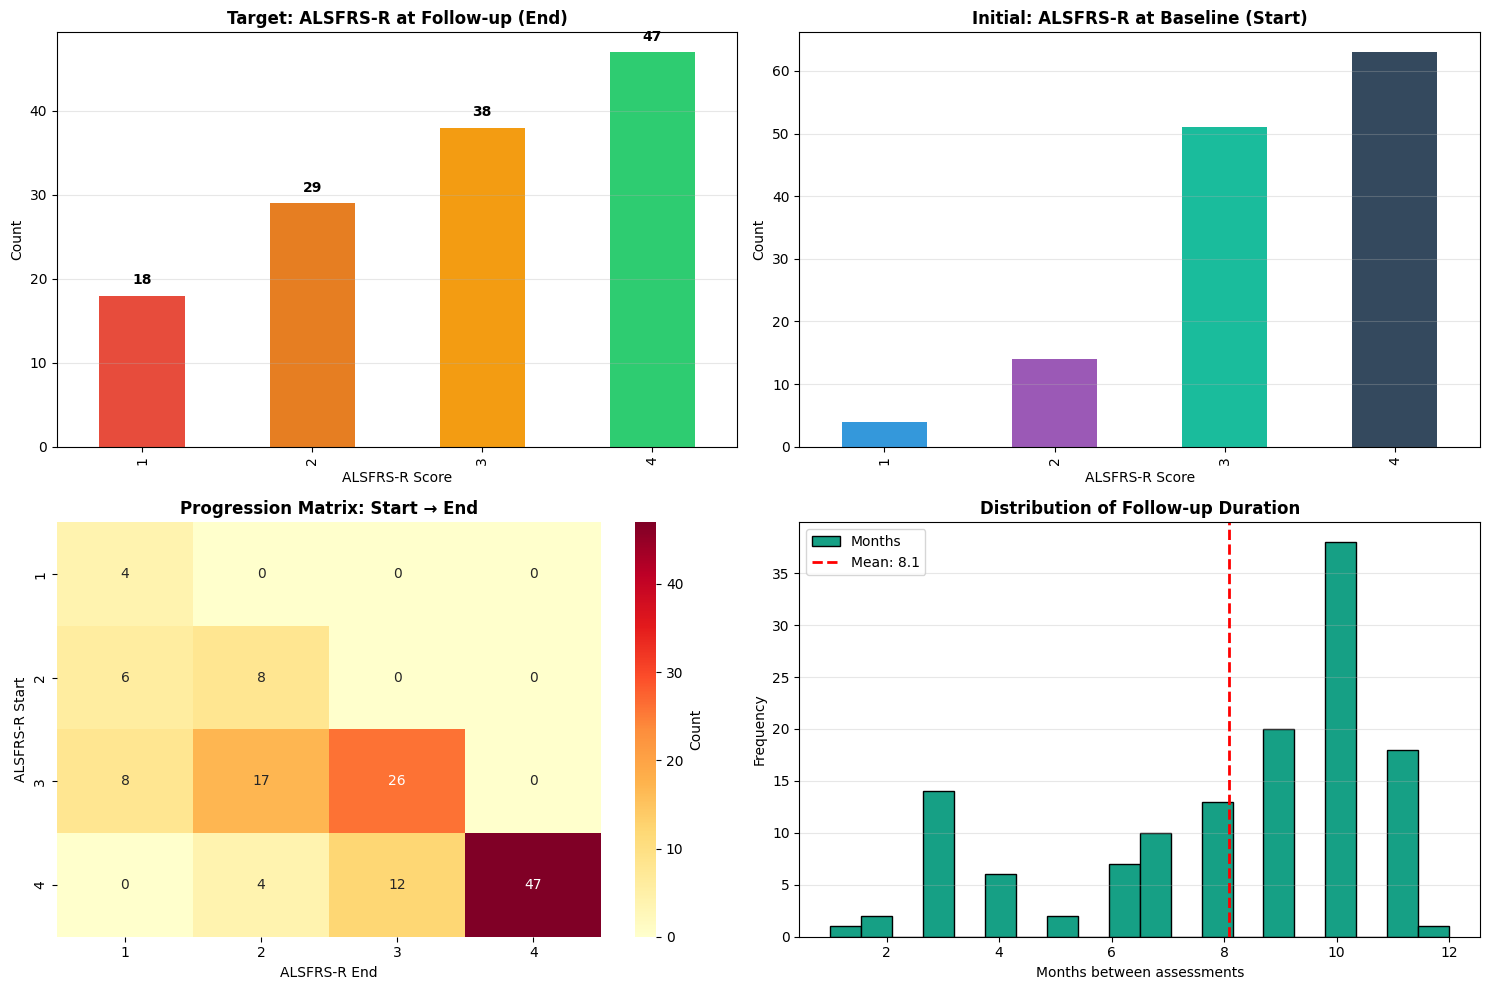


Key Statistics:
  Average follow-up: 8.08 ± 2.72 months
  Age range: 23-89 years
  Gender: {'M': 81, 'F': 51}
  Class balance: {1: 13.64, 2: 21.97, 3: 28.79, 4: 35.61}%


In [7]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Target class distribution (ALSFRS-R_end)
ax1 = axes[0, 0]
class_counts = df_full['ALSFRS--R_end'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=ax1, color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'])
ax1.set_title('Target: ALSFRS-R at Follow-up (End)', fontsize=12, fontweight='bold')
ax1.set_xlabel('ALSFRS-R Score')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Initial class distribution (ALSFRS-R_start)
ax2 = axes[0, 1]
start_counts = df_full['ALSFRS--R_start'].value_counts().sort_index()
start_counts.plot(kind='bar', ax=ax2, color=['#3498db', '#9b59b6', '#1abc9c', '#34495e'])
ax2.set_title('Initial: ALSFRS-R at Baseline (Start)', fontsize=12, fontweight='bold')
ax2.set_xlabel('ALSFRS-R Score')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

# 3. Progression matrix (Start vs End)
ax3 = axes[1, 0]
progression_matrix = pd.crosstab(df_full['ALSFRS--R_start'], df_full['ALSFRS--R_end'])
sns.heatmap(progression_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_title('Progression Matrix: Start → End', fontsize=12, fontweight='bold')
ax3.set_xlabel('ALSFRS-R End')
ax3.set_ylabel('ALSFRS-R Start')

# 4. Time distribution
ax4 = axes[1, 1]
df_full['Months'].plot(kind='hist', bins=20, ax=ax4, color='#16a085', edgecolor='black')
ax4.set_title('Distribution of Follow-up Duration', fontsize=12, fontweight='bold')
ax4.set_xlabel('Months between assessments')
ax4.set_ylabel('Frequency')
ax4.grid(axis='y', alpha=0.3)
ax4.axvline(df_full['Months'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df_full["Months"].mean():.1f}', linewidth=2)
ax4.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Statistics:")
print(f"  Average follow-up: {df_full['Months'].mean():.2f} ± {df_full['Months'].std():.2f} months")
print(f"  Age range: {df_full['Age'].min()}-{df_full['Age'].max()} years")
print(f"  Gender: {df_full['Sex'].value_counts().to_dict()}")
print(f"  Class balance: {(class_counts / len(df_full) * 100).round(2).to_dict()}%")

### 3.3 Data Preparation Function

In [8]:
def prepare_file_paths(df: pd.DataFrame, task_dir: Path) -> Tuple[List[List[str]], np.ndarray, np.ndarray]:
    """
    Prepare file paths and labels from dataframe.
    
    Returns:
        audio_files: List of lists, where each inner list contains 8 audio file paths
        labels: Target labels (ALSFRS--R_end) - THIS IS THE KEY COLUMN!
        metadata: Array of [Age, Sex_encoded, Months, ALSFRS--R_start]
    """
    audio_types = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU',
                   'rhythmKA', 'rhythmPA', 'rhythmTA']
    
    audio_files = []
    labels = []
    metadata = []
    
    for _, row in df.iterrows():
        patient_id = row['ID']
        
        # Collect all 8 audio files for this patient
        patient_files = []
        all_exist = True
        
        for audio_type in audio_types:
            file_path = task_dir / audio_type / f"{patient_id}_{audio_type}.wav"
            if file_path.exists():
                patient_files.append(str(file_path))
            else:
                all_exist = False
                print(f"Warning: Missing file {file_path}")
                break
        
        if all_exist and len(patient_files) == 8:
            audio_files.append(patient_files)
            
            # TARGET: ALSFRS--R_end (progression outcome)
            labels.append(row['ALSFRS--R_end'])
            
            # Encode metadata features
            sex_encoded = 1 if row['Sex'] == 'M' else 0
            metadata.append([
                row['Age'],
                sex_encoded,
                row['Months'],
                row['ALSFRS--R_start']  # Initial score as feature
            ])
    
    return audio_files, np.array(labels), np.array(metadata)

# Prepare ALL data
print("\nPreparing data...")
all_files, y_all, metadata_all = prepare_file_paths(df_full, TASK_DIR)

print(f"\n✓ Data prepared:")
print(f"  Total samples: {len(all_files)}")
print(f"  Files per sample: {len(all_files[0]) if all_files else 0}")
print(f"  Metadata features: {metadata_all.shape[1]} (Age, Sex, Months, ALSFRS-R_start)")
print(f"  Target distribution: {np.bincount(y_all)}")
print(f"  Target labels (first 10): {y_all[:10]}")


Preparing data...

✓ Data prepared:
  Total samples: 132
  Files per sample: 8
  Metadata features: 4 (Age, Sex, Months, ALSFRS-R_start)
  Target distribution: [ 0 18 29 38 47]
  Target labels (first 10): [4 3 1 3 3 2 4 4 4 2]


---
## 4. Feature Extraction

### 4.1 Load Pre-trained Models

In [ ]:
print("Loading pre-trained models...\n")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Wav2Vec2
print("\n1. Loading Wav2Vec2...")
wav2vec_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC2_CONFIG['model_name'])
wav2vec_model = Wav2Vec2Model.from_pretrained(WAV2VEC2_CONFIG['model_name']).to(device)
wav2vec_model.eval()
print(f"   ✓ Wav2Vec2 loaded: {WAV2VEC2_CONFIG['model_name']}")
print(f"   Hidden size: {wav2vec_model.config.hidden_size}")

# Load HuBERT
print("\n2. Loading HuBERT...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_CONFIG['model_name'])
hubert_model = HubertModel.from_pretrained(HUBERT_CONFIG['model_name']).to(device)
hubert_model.eval()
print(f"   ✓ HuBERT loaded: {HUBERT_CONFIG['model_name']}")
print(f"   Hidden size: {hubert_model.config.hidden_size}")

print("\n✅ All models loaded successfully!")

Loading pre-trained models...

Using device: cpu

1. Loading Wav2Vec2...


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Wav2Vec2 loaded: facebook/wav2vec2-large-960h
   Hidden size: 1024

2. Loading HuBERT...
   ✓ HuBERT loaded: facebook/hubert-large-ls960-ft
   Hidden size: 1024

✅ All models loaded successfully!


### 4.2 Feature Extraction Functions

In [10]:
def extract_wav2vec2_features(audio_path: str,
                             processor: Wav2Vec2Processor,
                             model: Wav2Vec2Model,
                             device: torch.device,
                             layers: List[int],
                             pooling: str = "mean",
                             layer_fusion: str = "concat") -> Optional[np.ndarray]:
    """
    Extract Wav2Vec2 features from audio file.
    """
    try:
        # Load and preprocess audio
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Resample if needed
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Process with Wav2Vec2
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        # Extract from specified layers
        layer_features = []
        for layer_idx in layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            
            # Apply pooling
            if pooling == "mean":
                pooled = np.mean(hidden_state, axis=0)
            elif pooling == "max":
                pooled = np.max(hidden_state, axis=0)
            elif pooling == "first":
                pooled = hidden_state[0]
            elif pooling == "last":
                pooled = hidden_state[-1]
            
            layer_features.append(pooled)
        
        # Fuse layers
        if layer_fusion == "concat":
            features = np.concatenate(layer_features)
        elif layer_fusion == "mean":
            features = np.mean(layer_features, axis=0)
        
        return features
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None


def extract_hubert_features(audio_path: str,
                           processor: Wav2Vec2FeatureExtractor,
                           model: HubertModel,
                           device: torch.device,
                           layers: List[int],
                           pooling: str = "mean",
                           layer_fusion: str = "concat") -> Optional[np.ndarray]:
    """
    Extract HuBERT features from audio file.
    """
    try:
        # Load and preprocess audio
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Resample if needed
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Process with HuBERT
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        # Extract from specified layers
        layer_features = []
        for layer_idx in layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            
            # Apply pooling
            if pooling == "mean":
                pooled = np.mean(hidden_state, axis=0)
            elif pooling == "max":
                pooled = np.max(hidden_state, axis=0)
            elif pooling == "first":
                pooled = hidden_state[0]
            elif pooling == "last":
                pooled = hidden_state[-1]
            
            layer_features.append(pooled)
        
        # Fuse layers
        if layer_fusion == "concat":
            features = np.concatenate(layer_features)
        elif layer_fusion == "mean":
            features = np.mean(layer_features, axis=0)
        
        return features
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


### 4.3 Extract Features from All Audio Files

In [11]:
def extract_all_features(file_groups: List[List[str]], 
                        fusion_strategy: str = "concat") -> np.ndarray:
    """
    Extract both Wav2Vec2 and HuBERT features from all audio files.
    
    Args:
        file_groups: List of lists, each containing 8 audio file paths
        fusion_strategy: How to combine Wav2Vec2 and HuBERT features
    
    Returns:
        features: Array of shape (n_samples, feature_dim)
    """
    all_features = []
    
    for file_group in tqdm(file_groups, desc="Extracting features"):
        sample_wav2vec_features = []
        sample_hubert_features = []
        
        # Extract features from each of the 8 audio files
        for audio_file in file_group:
            # Wav2Vec2 features
            wav2vec_feat = extract_wav2vec2_features(
                audio_file, wav2vec_processor, wav2vec_model, device,
                layers=WAV2VEC2_CONFIG['layers'],
                pooling=WAV2VEC2_CONFIG['pooling'],
                layer_fusion=WAV2VEC2_CONFIG['layer_fusion']
            )
            
            # HuBERT features
            hubert_feat = extract_hubert_features(
                audio_file, hubert_processor, hubert_model, device,
                layers=HUBERT_CONFIG['layers'],
                pooling=HUBERT_CONFIG['pooling'],
                layer_fusion=HUBERT_CONFIG['layer_fusion']
            )
            
            if wav2vec_feat is not None and hubert_feat is not None:
                sample_wav2vec_features.append(wav2vec_feat)
                sample_hubert_features.append(hubert_feat)
        
        # Combine features from all 8 files
        if len(sample_wav2vec_features) == 8 and len(sample_hubert_features) == 8:
            # Concatenate across files
            wav2vec_combined = np.concatenate(sample_wav2vec_features)
            hubert_combined = np.concatenate(sample_hubert_features)
            
            # Fuse Wav2Vec2 and HuBERT features
            if fusion_strategy == "concat":
                final_features = np.concatenate([wav2vec_combined, hubert_combined])
            elif fusion_strategy == "average":
                final_features = np.mean([wav2vec_combined, hubert_combined], axis=0)
            
            all_features.append(final_features)
    
    return np.array(all_features)

# Extract features for ALL data
print("\n" + "="*80)
print("FEATURE EXTRACTION")
print("="*80)
print("\nExtracting features from all samples...")
print("This may take several minutes...\n")

X_audio = extract_all_features(all_files, fusion_strategy=FUSION_STRATEGY)

print(f"\n✓ Feature extraction complete:")
print(f"  Audio features shape: {X_audio.shape}")
print(f"  Samples: {X_audio.shape[0]}")
print(f"  Audio feature dimension: {X_audio.shape[1]}")


FEATURE EXTRACTION

Extracting features from all samples...
This may take several minutes...



Extracting features: 100%|██████████| 132/132 [17:54<00:00,  8.14s/it]


✓ Feature extraction complete:
  Audio features shape: (132, 81920)
  Samples: 132
  Audio feature dimension: 81920


### 4.4 Combine Audio and Metadata Features

In [15]:
### 4.4 Combine Audio and Metadata Features

# Combine audio features with metadata
X_all = np.concatenate([X_audio, metadata_all], axis=1)
y_all_original = y_all  # Keep original for reference

# Transform labels from [1,2,3,4] to [0,1,2,3] for sklearn compatibility
# This is required because XGBoost expects classes starting at 0
y_all_final = y_all - 1

print("\n" + "="*80)
print("FINAL FEATURE MATRIX & LABEL TRANSFORMATION")
print("="*80)
print(f"Total samples: {X_all.shape[0]}")
print(f"Total features: {X_all.shape[1]}")
print(f"  - Audio features (Wav2Vec2 + HuBERT): {X_audio.shape[1]}")
print(f"  - Metadata features: {metadata_all.shape[1]} (Age, Sex, Months, ALSFRS-R_start)")

print(f"\nLabel Transformation:")
print(f"  Original ALSFRS-R labels: {np.unique(y_all_original)} → Target labels: {np.unique(y_all_final)}")
print(f"  Mapping:")
print(f"    ALSFRS-R 1 (Severe dysarthria)   → Class 0")
print(f"    ALSFRS-R 2 (Moderate dysarthria) → Class 1")
print(f"    ALSFRS-R 3 (Mild dysarthria)     → Class 2")
print(f"    ALSFRS-R 4 (No dysarthria)       → Class 3")

print(f"\nFinal Target Distribution:")
for original, transformed in zip([1,2,3,4], [0,1,2,3]):
    count = np.sum(y_all_final == transformed)
    print(f"  Class {transformed} (ALSFRS-R={original}): {count} samples")

print("="*80)


FINAL FEATURE MATRIX & LABEL TRANSFORMATION
Total samples: 132
Total features: 81924
  - Audio features (Wav2Vec2 + HuBERT): 81920
  - Metadata features: 4 (Age, Sex, Months, ALSFRS-R_start)

Label Transformation:
  Original ALSFRS-R labels: [1 2 3 4] → Target labels: [0 1 2 3]
  Mapping:
    ALSFRS-R 1 (Severe dysarthria)   → Class 0
    ALSFRS-R 2 (Moderate dysarthria) → Class 1
    ALSFRS-R 3 (Mild dysarthria)     → Class 2
    ALSFRS-R 4 (No dysarthria)       → Class 3

Final Target Distribution:
  Class 0 (ALSFRS-R=1): 18 samples
  Class 1 (ALSFRS-R=2): 29 samples
  Class 2 (ALSFRS-R=3): 38 samples
  Class 3 (ALSFRS-R=4): 47 samples


---
## 5. Model Training with 5-Fold Cross-Validation

### 5.1 Define Models and Pipelines

In [16]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_RANDOM_STATE)

# Define scoring metric
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Define models
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_split=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            random_state=42,
            eval_metric='mlogloss',
            n_jobs=-1
        ))
    ]),
    
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            C=10,
            kernel='rbf',
            gamma='scale',
            class_weight='balanced',
            random_state=42,
            probability=True
        ))
    ]),
    
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ))
    ]),
}

print("✓ Models defined:")
for name in models.keys():
    print(f"  - {name}")

✓ Models defined:
  - Random Forest
  - XGBoost
  - SVM
  - Gradient Boosting


### 5.2 Perform 5-Fold Cross-Validation for Each Model

In [17]:
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION")
print("="*80)

results = {}

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name}")
    print(f"{'='*80}")
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_all, y_all_final,
        cv=cv,
        scoring={
            'f1_macro': f1_macro_scorer,
            'accuracy': 'accuracy',
            'balanced_accuracy': 'balanced_accuracy'
        },
        return_train_score=True,
        n_jobs=-1
    )
    
    # Extract results
    f1_scores = cv_results['test_f1_macro']
    acc_scores = cv_results['test_accuracy']
    bal_acc_scores = cv_results['test_balanced_accuracy']
    
    # Store results
    results[model_name] = {
        'f1_macro_mean': np.mean(f1_scores),
        'f1_macro_std': np.std(f1_scores),
        'f1_macro_scores': f1_scores,
        'accuracy_mean': np.mean(acc_scores),
        'accuracy_std': np.std(acc_scores),
        'balanced_accuracy_mean': np.mean(bal_acc_scores),
        'balanced_accuracy_std': np.std(bal_acc_scores),
    }
    
    # Print results
    print(f"\nResults across {N_FOLDS} folds:")
    print(f"  F1-Macro: {results[model_name]['f1_macro_mean']:.4f} ± {results[model_name]['f1_macro_std']:.4f}")
    print(f"  Accuracy: {results[model_name]['accuracy_mean']:.4f} ± {results[model_name]['accuracy_std']:.4f}")
    print(f"  Balanced Accuracy: {results[model_name]['balanced_accuracy_mean']:.4f} ± {results[model_name]['balanced_accuracy_std']:.4f}")
    print(f"\n  Individual F1 scores per fold:")
    for i, score in enumerate(f1_scores, 1):
        print(f"    Fold {i}: {score:.4f}")

print("\n" + "="*80)
print("CROSS-VALIDATION COMPLETE")
print("="*80)


5-FOLD CROSS-VALIDATION

Model: Random Forest

Results across 5 folds:
  F1-Macro: 0.4073 ± 0.0399
  Accuracy: 0.4311 ± 0.0602
  Balanced Accuracy: 0.4289 ± 0.0451

  Individual F1 scores per fold:
    Fold 1: 0.4733
    Fold 2: 0.4132
    Fold 3: 0.3497
    Fold 4: 0.4087
    Fold 5: 0.3917

Model: XGBoost

Results across 5 folds:
  F1-Macro: 0.5642 ± 0.0438
  Accuracy: 0.6134 ± 0.0389
  Balanced Accuracy: 0.5786 ± 0.0655

  Individual F1 scores per fold:
    Fold 1: 0.5161
    Fold 2: 0.6223
    Fold 3: 0.5201
    Fold 4: 0.6074
    Fold 5: 0.5548

Model: SVM

Results across 5 folds:
  F1-Macro: 0.3851 ± 0.0649
  Accuracy: 0.4154 ± 0.0788
  Balanced Accuracy: 0.3804 ± 0.0661

  Individual F1 scores per fold:
    Fold 1: 0.4911
    Fold 2: 0.4285
    Fold 3: 0.3416
    Fold 4: 0.3475
    Fold 5: 0.3170

Model: Gradient Boosting

Results across 5 folds:
  F1-Macro: 0.4404 ± 0.1047
  Accuracy: 0.5151 ± 0.0559
  Balanced Accuracy: 0.4598 ± 0.0938

  Individual F1 scores per fold:
    Fo

### 5.3 Create Ensemble Models and Evaluate

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE MODELS")
print("="*80)

# ============================================================================
# VOTING ENSEMBLE
# ============================================================================
print("\n1. Voting Ensemble (Soft Voting)")
print("   Combining: Random Forest + XGBoost + SVM + Gradient Boosting")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('svm', models['SVM']),
        ('gb', models['Gradient Boosting'])
    ],
    voting='soft',
    n_jobs=-1
)

print("   Training voting ensemble with 5-fold CV...")
voting_cv_results = cross_validate(
    voting_clf, X_all, y_all_final,
    cv=cv,
    scoring={'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

voting_f1_scores = voting_cv_results['test_f1_macro']
voting_acc_scores = voting_cv_results['test_accuracy']

results['Voting Ensemble'] = {
    'f1_macro_mean': np.mean(voting_f1_scores),
    'f1_macro_std': np.std(voting_f1_scores),
    'f1_macro_scores': voting_f1_scores,
    'accuracy_mean': np.mean(voting_acc_scores),
    'accuracy_std': np.std(voting_acc_scores),
}

print(f"\n   Results:")
print(f"   F1-Macro:  {results['Voting Ensemble']['f1_macro_mean']:.4f} ± {results['Voting Ensemble']['f1_macro_std']:.4f}")
print(f"   Accuracy:  {results['Voting Ensemble']['accuracy_mean']:.4f} ± {results['Voting Ensemble']['accuracy_std']:.4f}")
print(f"\n   Individual F1 scores per fold:")
for i, score in enumerate(voting_f1_scores, 1):
    print(f"     Fold {i}: {score:.4f}")

print("\n" + "="*80)
print("ENSEMBLE EVALUATION COMPLETE")
print("="*80)


ENSEMBLE MODELS

1. Voting Ensemble (Soft Voting)
   Combining: Random Forest + XGBoost + Gradient Boosting
   Training voting ensemble with 5-fold CV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


---
## 6. Results Analysis and Visualization

### 6.1 Results Summary Table

In [ ]:
# Create results DataFrame
results_df = pd.DataFrame([
    {
        'Model': name,
        'F1-Macro (Mean)': data['f1_macro_mean'],
        'F1-Macro (Std)': data['f1_macro_std'],
        'F1-Macro (Formatted)': f"{data['f1_macro_mean']:.4f} ± {data['f1_macro_std']:.4f}"
    }
    for name, data in results.items()
])

results_df = results_df.sort_values('F1-Macro (Mean)', ascending=False)

print("\n" + "="*80)
print("FINAL RESULTS (5-FOLD CROSS-VALIDATION)")
print("="*80)
print(results_df[['Model', 'F1-Macro (Formatted)']].to_string(index=False))
print("\n" + "="*80)

# Best model
best_model = results_df.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"   F1-Macro: {best_model['F1-Macro (Formatted)']}")
print(f"\n📊 COMPARISON:")
print(f"   Baseline (PART): 0.5830")
print(f"   Current Leader (ISDS): 0.5794")
print(f"   Our Best: {best_model['F1-Macro (Mean)']:.4f}")
improvement = (best_model['F1-Macro (Mean)'] - 0.583) * 100
print(f"   Improvement over baseline: {improvement:+.2f}%")
print("="*80)

### 6.2 Visualization

In [ ]:
# Create comprehensive visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean F1 scores with error bars
models_list = results_df['Model'].tolist()
means = results_df['F1-Macro (Mean)'].tolist()
stds = results_df['F1-Macro (Std)'].tolist()

colors = ['#2ecc71' if m > 0.583 else '#e74c3c' for m in means]
bars = ax1.barh(models_list, means, xerr=stds, color=colors, alpha=0.7, 
                edgecolor='black', linewidth=1.5, capsize=5)

# Add baseline lines
ax1.axvline(0.583, color='red', linestyle='--', linewidth=2, 
            label='Baseline (PART: 0.583)', alpha=0.7)
ax1.axvline(0.5794, color='orange', linestyle='--', linewidth=2,
            label='Leader (ISDS: 0.5794)', alpha=0.7)

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    ax1.text(mean + 0.01, i, f'{mean:.4f}±{std:.4f}', 
             va='center', fontweight='bold', fontsize=9)

ax1.set_xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance (5-Fold CV)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(min(means) - 0.05, max(means) + 0.08)

# Plot 2: Individual fold scores
fold_data = []
for name in models_list:
    if 'f1_macro_scores' in results[name]:
        for fold, score in enumerate(results[name]['f1_macro_scores'], 1):
            fold_data.append({'Model': name, 'Fold': fold, 'F1-Macro': score})

fold_df = pd.DataFrame(fold_data)
sns.boxplot(data=fold_df, y='Model', x='F1-Macro', ax=ax2, 
            order=models_list, palette='Set2')
ax2.set_xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('')
ax2.set_title('Score Distribution Across Folds', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(0.583, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Statistical Comparison

In [ ]:
# Create detailed fold-by-fold comparison
fold_comparison = pd.DataFrame({
    name: results[name]['f1_macro_scores'] 
    for name in models_list if 'f1_macro_scores' in results[name]
})
fold_comparison.index = [f'Fold {i+1}' for i in range(N_FOLDS)]

print("\n" + "="*80)
print("FOLD-BY-FOLD F1-MACRO SCORES")
print("="*80)
print(fold_comparison.to_string())
print("\n" + "="*80)
print("STATISTICS")
print("="*80)
print(fold_comparison.describe().loc[['mean', 'std', 'min', 'max']])
print("="*80)

---
## 7. Save Results

### 7.1 Save Experiment Configuration and Results

In [ ]:
# Create experiment directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f"task2_5fold_cv_{timestamp}"
experiment_dir = OUTPUT_DIR / experiment_name
experiment_dir.mkdir(exist_ok=True)

# Save configuration
config = {
    "experiment_name": experiment_name,
    "timestamp": datetime.now().isoformat(),
    "task": "Task 2 - ALS Progression Prediction",
    "evaluation_strategy": f"{N_FOLDS}-Fold Stratified Cross-Validation",
    "feature_extraction": {
        "wav2vec2": WAV2VEC2_CONFIG,
        "hubert": HUBERT_CONFIG,
        "fusion_strategy": FUSION_STRATEGY
    },
    "dataset": {
        "total_samples": len(X_all),
        "num_classes": len(np.unique(y_all_final)),
        "feature_dim_audio": X_audio.shape[1],
        "feature_dim_metadata": metadata_all.shape[1],
        "feature_dim_total": X_all.shape[1],
        "class_distribution": {int(k): int(v) for k, v in zip(*np.unique(y_all_final, return_counts=True))}
    },
    "results": {
        name: {
            "f1_macro_mean": float(data['f1_macro_mean']),
            "f1_macro_std": float(data['f1_macro_std']),
            "f1_macro_scores": [float(s) for s in data['f1_macro_scores']] if 'f1_macro_scores' in data else None
        }
        for name, data in results.items()
    },
    "best_model": {
        "name": best_model['Model'],
        "f1_macro_mean": float(best_model['F1-Macro (Mean)']),
        "f1_macro_std": float(best_model['F1-Macro (Std)']),
        "baseline_f1": 0.583,
        "improvement_over_baseline_percent": float(improvement)
    }
}

with open(experiment_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save results DataFrame
results_df.to_csv(experiment_dir / 'results_summary.csv', index=False)

# Save fold-by-fold comparison
fold_comparison.to_csv(experiment_dir / 'fold_by_fold_comparison.csv')

print(f"\n✓ Results saved to: {experiment_dir}")
print(f"  - config.json")
print(f"  - results_summary.csv")
print(f"  - fold_by_fold_comparison.csv")

---
## 8. Final Summary and Recommendations

### 8.1 Experiment Summary

In [ ]:
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"\nTask: SAND Challenge - Task 2 (ALS Progression Prediction)")
print(f"Experiment: {experiment_name}")
print(f"Evaluation: {N_FOLDS}-Fold Stratified Cross-Validation")
print(f"\nFeature Extraction:")
print(f"  - Wav2Vec2: {WAV2VEC2_CONFIG['model_name']}")
print(f"  - HuBERT: {HUBERT_CONFIG['model_name']}")
print(f"  - Fusion: {FUSION_STRATEGY}")
print(f"\nDataset:")
print(f"  - Total samples: {len(X_all)}")
print(f"  - Total features: {X_all.shape[1]}")
print(f"  - Target: ALSFRS--R_end (progression outcome)")
print(f"\nTop 3 Models:")
for i, row in results_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: {row['F1-Macro (Formatted)']}")
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   F1-Macro: {best_model['F1-Macro (Formatted)']}")
print(f"   Baseline: 0.5830")
print(f"   Improvement: {improvement:+.2f}%")
print(f"\nResults saved to: {experiment_dir}")
print("="*80)

### 8.2 Next Steps and Improvements

**Potential improvements to explore:**

1. **Hyperparameter Tuning**
   - Use GridSearchCV or Optuna within CV folds
   - Optimize fusion strategies
   
2. **Feature Engineering**
   - Try different layer combinations
   - Add attention-based fusion
   - Temporal progression features (rate of change)
   
3. **Data Augmentation**
   - Audio augmentation (pitch, speed, noise)
   - SMOTE within CV folds
   
4. **Advanced Ensembles**
   - Weighted voting based on CV performance
   - Multi-level stacking
   
5. **Model Interpretability**
   - Feature importance analysis
   - SHAP values for understanding predictions

**This notebook provides a robust baseline following your professor's guidelines!**